

```
## 📊 SQL Customer Analytics Project

This project demonstrates how SQL can be used alongside Python to extract business insights from e-commerce data.

We simulate a real-world analytics workflow using SQLite and perform:
- Revenue analysis
- Customer segmentation
- Product performance analysis
- Time-based trends
```



In [22]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('/content/online_retail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [11]:
# 1. Handle missing values
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows where CustomerID is missing, as it's crucial for customer analytics
df.dropna(subset=['CustomerID'], inplace=True)

# 2. Convert CustomerID to integer type
df['CustomerID'] = df['CustomerID'].astype(int)

# 3. Convert InvoiceDate to datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 4. Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 5. Remove rows with negative Quantity or UnitPrice
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 6. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 7. Create revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nShape of DataFrame after cleaning:", df.shape)
print("\nFirst 5 rows of cleaned data:")
print(df.head())

Missing values before cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Shape of DataFrame after cleaning: (392692, 9)

First 5 rows of cleaned data:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue



```
STORE IN **SQL**
```



In [12]:
conn = sqlite3.connect('ecommerce.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

392692

***CORE SQL ANALYSIS***


1.   Total revenue
2.   REVENUE BY COUNTRY

3. TOP CUSTOMERS
4. MONTHLY SALES TREND
5. TOP PRODUCTS
6. Best selling products by country

7. Customer segmentation
8. Average order Value


In [14]:
#Total Revenue

query = """
SELECT ROUND(SUM(Quantity * UnitPrice), 2) AS Total_Revenue
FROM sales;
"""
pd.read_sql(query, conn)

,Total_Revenue
0,8887208.89


In [15]:
#Revenue by country
query = """
SELECT Country,
       ROUND(SUM(Quantity * UnitPrice), 2) AS Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC;
"""
country_revenue = pd.read_sql(query, conn)
country_revenue.head()

,Country,Revenue
0,United Kingdom,7285024.64
1,Netherlands,285446.34
2,EIRE,265262.46
3,Germany,228678.40
4,France,208934.31


In [16]:
#Top customers
query = """
SELECT CustomerID,
       COUNT(DISTINCT InvoiceNo) AS Orders,
       ROUND(SUM(Quantity * UnitPrice), 2) AS Total_Spent
FROM sales
GROUP BY CustomerID
ORDER BY Total_Spent DESC
LIMIT 10;
"""
top_customers = pd.read_sql(query, conn)
top_customers

,CustomerID,Orders,Total_Spent
0,14646,73,280206.02
1,18102,60,259657.30
2,17450,46,194390.79
3,16446,2,168472.50
4,14911,201,143711.17
5,12415,21,124914.53
6,14156,55,117210.08
7,17511,31,91062.38
8,16029,63,80850.84
9,12346,1,77183.60


In [19]:
#monthly Sales trends
query = """
SELECT strftime('%Y-%m', InvoiceDate) AS Month,
       ROUND(SUM(Quantity * UnitPrice), 2) AS Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
"""
monthly = pd.read_sql(query, conn)
monthly

,Month,Revenue
0,2010-12,570422.73
1,2011-01,568101.31
2,2011-02,446084.92
3,2011-03,594081.76
4,2011-04,468374.33
5,2011-05,677355.15
6,2011-06,660046.05
7,2011-07,598962.90
8,2011-08,644051.04
9,2011-09,950690.20


In [18]:
#Top products

query = """
SELECT Description,
       SUM(Quantity) AS Total_Sold,
       ROUND(SUM(Quantity * UnitPrice), 2) AS Revenue
FROM sales
GROUP BY Description
ORDER BY Total_Sold DESC
LIMIT 10;
"""
top_products = pd.read_sql(query, conn)
top_products

,Description,Total_Sold,Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,13558.41
3,JUMBO BAG RED RETROSPOT,46078,85040.54
4,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10
5,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03
6,PACK OF 72 RETROSPOT CAKE CASES,33670,16381.88
7,POPCORN HOLDER,30919,23417.51
8,RABBIT NIGHT LIGHT,27153,51251.24
9,MINI PAINT SET VINTAGE,26076,16039.24


In [26]:
#best selling products by country
query = """
SELECT Country, Description,
       SUM(Quantity) AS Total_Sold
FROM sales
GROUP BY Country, Description
ORDER BY Country, Total_Sold DESC;
"""
pd.read_sql(query, conn).head(20)

,Country,Description,Total_Sold
0,Australia,MINI PAINT SET VINTAGE,2952
1,Australia,RABBIT NIGHT LIGHT,1884
2,Australia,RED HARMONICA IN BOX,1704
3,Australia,RED TOADSTOOL LED NIGHT LIGHT,1344
4,Australia,HOMEMADE JAM SCENTED CANDLES,1080
5,Australia,DOLLY GIRL LUNCH BOX,1024
6,Australia,SPACEBOY LUNCH BOX,960
7,Australia,MINI JIGSAW SPACEBOY,720
8,Australia,BLUE HARMONICA IN BOX,720
9,Australia,4 TRADITIONAL SPINNING TOPS,700


In [27]:
#customer segmentation
query = """
SELECT CustomerID,
       COUNT(DISTINCT InvoiceNo) AS Frequency,
       ROUND(SUM(Quantity * UnitPrice), 2) AS Monetary
FROM sales
GROUP BY CustomerID;
"""
customer_seg = pd.read_sql(query, conn)
customer_seg.head()

,CustomerID,Frequency,Monetary
0,12346,1,77183.60
1,12347,7,4310.00
2,12348,4,1797.24
3,12349,1,1757.55
4,12350,1,334.40


In [29]:
#Average order value

query = """
SELECT CustomerID,
       ROUND(SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo), 2) AS Avg_Order_Value
FROM sales
GROUP BY CustomerID
ORDER BY Avg_Order_Value DESC
LIMIT 10;
"""
pd.read_sql(query, conn)



,CustomerID,Avg_Order_Value
0,16446,84236.25
1,12346,77183.60
2,15749,14844.77
3,15098,13305.50
4,12357,6207.67
5,12415,5948.31
6,12590,4932.13
7,12688,4873.81
8,12752,4366.78
9,18102,4327.62


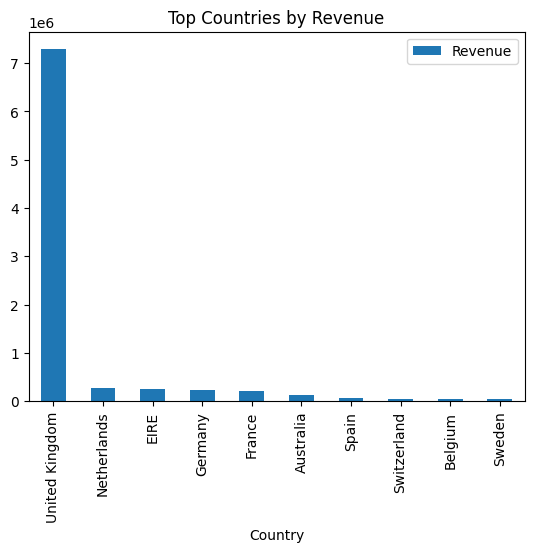

In [30]:
country_revenue.head(10).plot(kind='bar', x='Country', y='Revenue')
plt.title("Top Countries by Revenue")
plt.savefig('country_revenue.png')
plt.show()

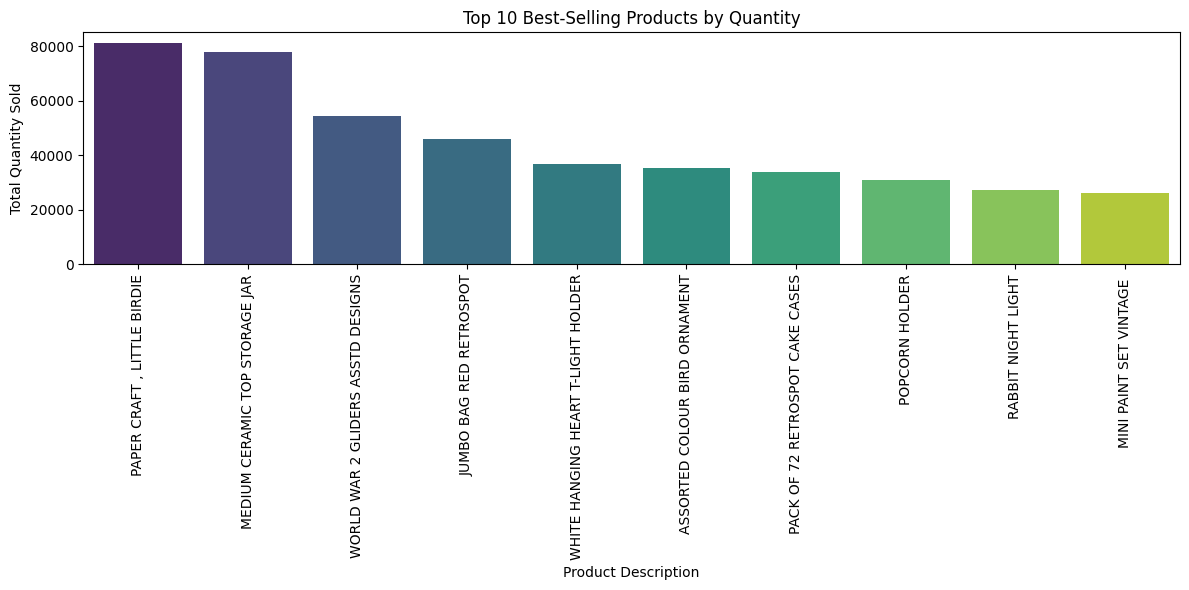

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Description', y='Total_Sold', data=top_products, palette='viridis', hue='Description', legend=False)
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

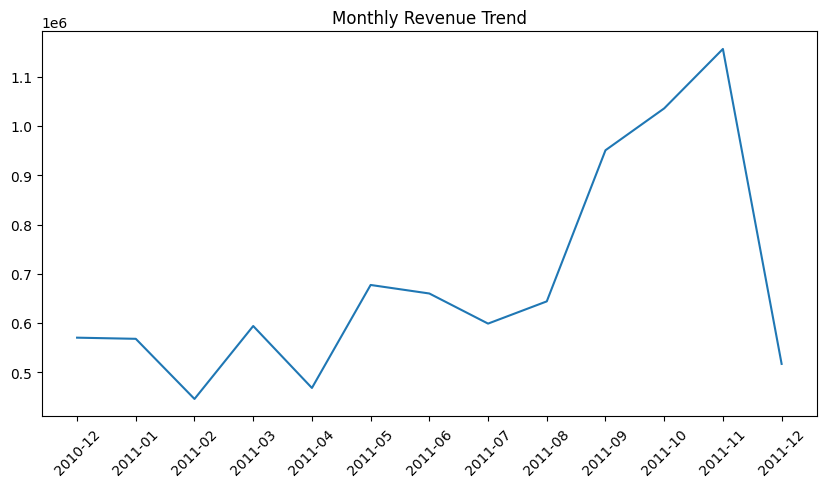

In [31]:
plt.figure(figsize=(10,5))
plt.plot(monthly['Month'], monthly['Revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.savefig('monthly_trend.png')
plt.show()

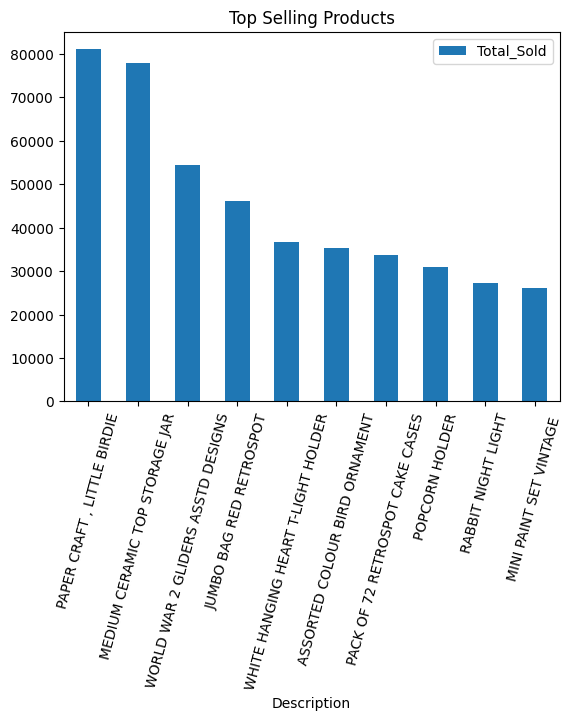

In [32]:
top_products.plot(kind='bar', x='Description', y='Total_Sold')
plt.xticks(rotation=75)
plt.title("Top Selling Products")
plt.savefig('top_products.png')
plt.show()



```
# ## 🔍 Key Business Insights

- The majority of revenue is generated from a few key countries, indicating geographic concentration.
- A small segment of customers contributes disproportionately to total revenue (high-value customers).
- Monthly trends reveal fluctuations, suggesting seasonal demand patterns.
- Certain products dominate sales, indicating strong customer preference and potential for targeted promotions.
- Customers with higher purchase frequency tend to generate significantly higher lifetime value.
```

